In [1]:
# ENTER ABSOLUTE PATH TO LOG DIRECTORY HERE
log_dir = "/home/ga53voq/master_thesis/logs/cave_exploration-2025-08-19_21-01-27/episode_2_cave_271_reward_4.40"

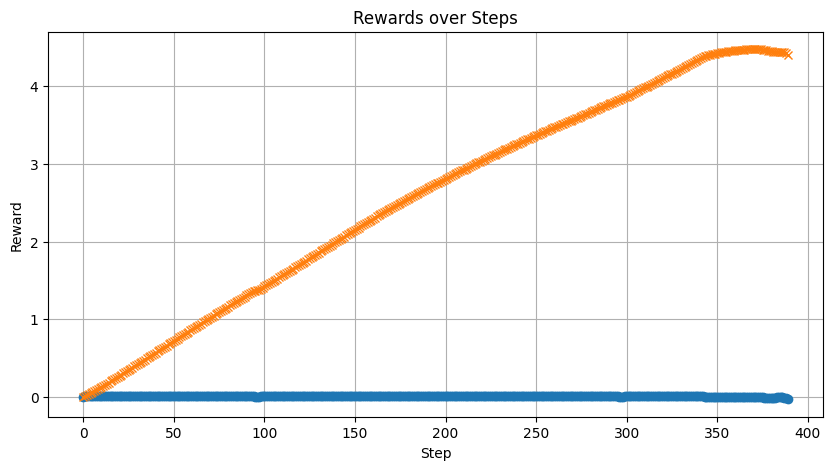

In [4]:
# Import necessary libraries
import os
import json
import matplotlib.pyplot as plt

if not os.path.exists(log_dir):
    print(f'Log directory does not exist: {log_dir}')
    exit(1)
detailed_files = [f for f in os.listdir(log_dir) if f.startswith('detailed_logs')]
rewards_file = detailed_files[0] if detailed_files else None
if rewards_file is None:
    print('No detailed_logs file found in the specified log directory.')
    exit(1)
rewards_file = os.path.join(log_dir, rewards_file)

# Load rewards from the JSON array log file
rewards = []

with open(rewards_file, 'r') as f:
    try:
        data = json.load(f)  # Expecting a list of dicts
        rewards = [entry.get('reward', 0.0) for entry in data]
        cumulative_rewards = [entry.get('cumulative_reward', 0.0) for entry in data]
    except Exception as e:
        print(f'Error loading JSON: {e}')


# Plot rewards over steps
if rewards:
    plt.figure(figsize=(10, 5))
    plt.plot(rewards, marker='o')
    plt.plot(cumulative_rewards, marker='x', linestyle='--', label='Cumulative Rewards')
    plt.title('Rewards over Steps')
    plt.xlabel('Step')
    plt.ylabel('Reward')
    plt.grid(True)
    plt.show()
else:
    print('No rewards found to plot.')

# Lidar directional data

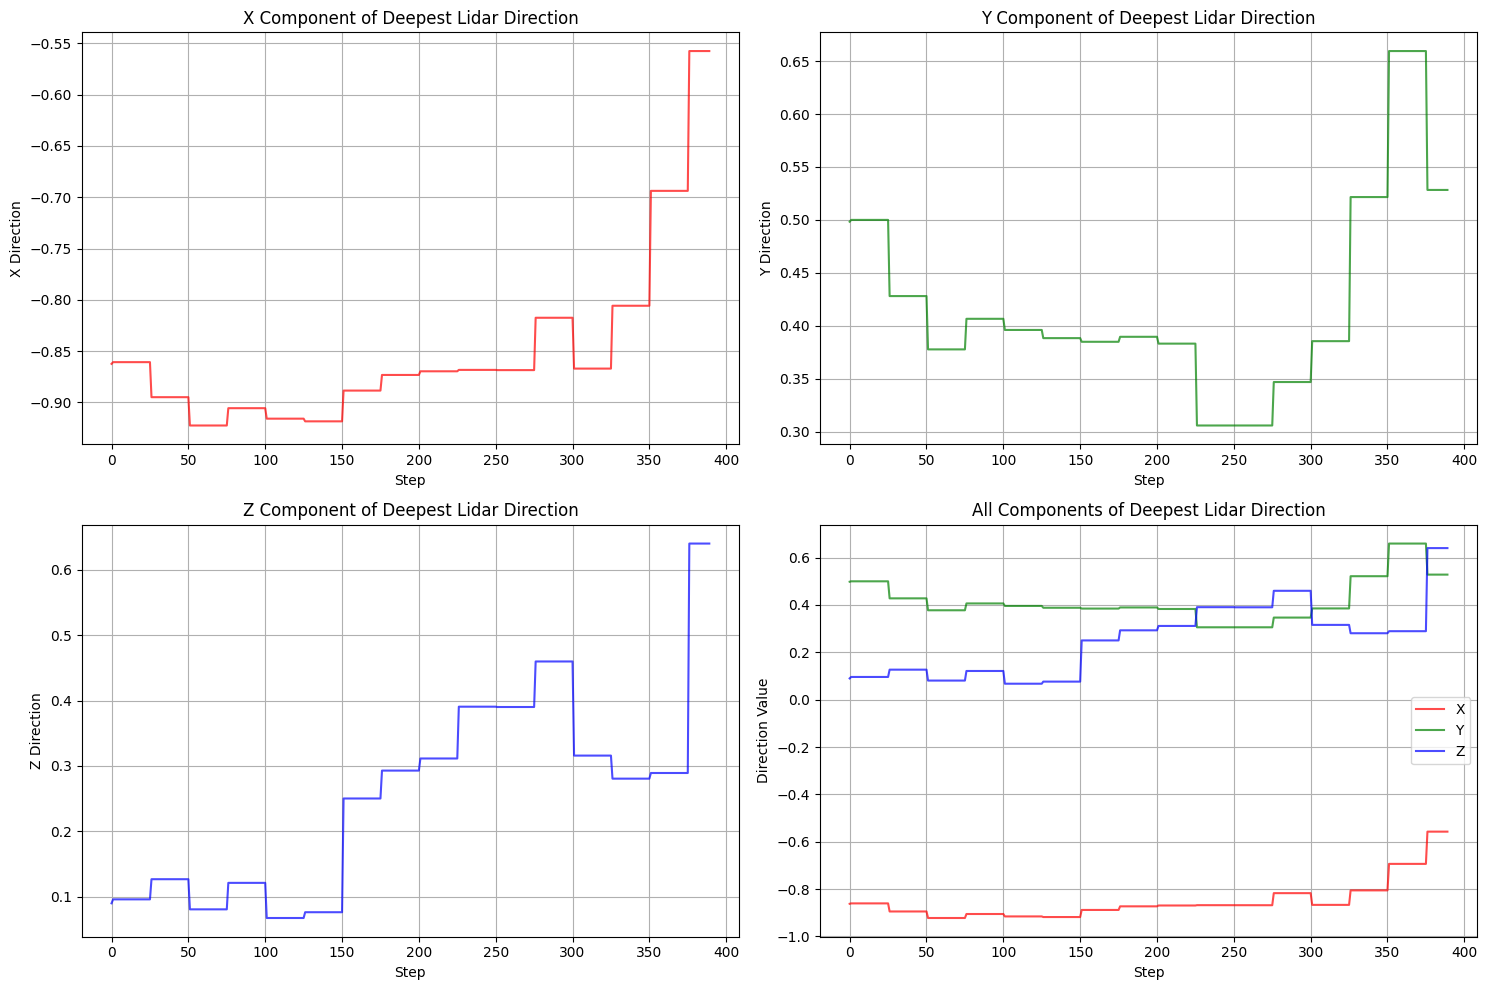

Total data points: 390
X component range: [-0.922, -0.558]
Y component range: [0.306, 0.660]
Z component range: [0.067, 0.640]


In [5]:
import numpy as np

# Extract deepest_lidar_direction data from the loaded data
lidar_directions = []
steps = []

for entry in data:
    if 'info' in entry and 'deepest_lidar_direction' in entry['info']:
        lidar_dir = entry['info']['deepest_lidar_direction']
        lidar_directions.append(lidar_dir)
        steps.append(entry['step'])

# Convert to numpy arrays for easier manipulation
lidar_directions = np.array(lidar_directions)

# Plot the lidar direction components over time
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Plot individual components
axes[0, 0].plot(steps, lidar_directions[:, 0], 'r-', alpha=0.7)
axes[0, 0].set_title('X Component of Deepest Lidar Direction')
axes[0, 0].set_xlabel('Step')
axes[0, 0].set_ylabel('X Direction')
axes[0, 0].grid(True)

axes[0, 1].plot(steps, lidar_directions[:, 1], 'g-', alpha=0.7)
axes[0, 1].set_title('Y Component of Deepest Lidar Direction')
axes[0, 1].set_xlabel('Step')
axes[0, 1].set_ylabel('Y Direction')
axes[0, 1].grid(True)

axes[1, 0].plot(steps, lidar_directions[:, 2], 'b-', alpha=0.7)
axes[1, 0].set_title('Z Component of Deepest Lidar Direction')
axes[1, 0].set_xlabel('Step')
axes[1, 0].set_ylabel('Z Direction')
axes[1, 0].grid(True)

# Plot all components together
axes[1, 1].plot(steps, lidar_directions[:, 0], 'r-', alpha=0.7, label='X')
axes[1, 1].plot(steps, lidar_directions[:, 1], 'g-', alpha=0.7, label='Y')
axes[1, 1].plot(steps, lidar_directions[:, 2], 'b-', alpha=0.7, label='Z')
axes[1, 1].set_title('All Components of Deepest Lidar Direction')
axes[1, 1].set_xlabel('Step')
axes[1, 1].set_ylabel('Direction Value')
axes[1, 1].legend()
axes[1, 1].grid(True)

plt.tight_layout()
plt.show()

# Print some statistics
print(f"Total data points: {len(lidar_directions)}")
print(f"X component range: [{np.min(lidar_directions[:, 0]):.3f}, {np.max(lidar_directions[:, 0]):.3f}]")
print(f"Y component range: [{np.min(lidar_directions[:, 1]):.3f}, {np.max(lidar_directions[:, 1]):.3f}]")
print(f"Z component range: [{np.min(lidar_directions[:, 2]):.3f}, {np.max(lidar_directions[:, 2]):.3f}]")

# Rewards over time

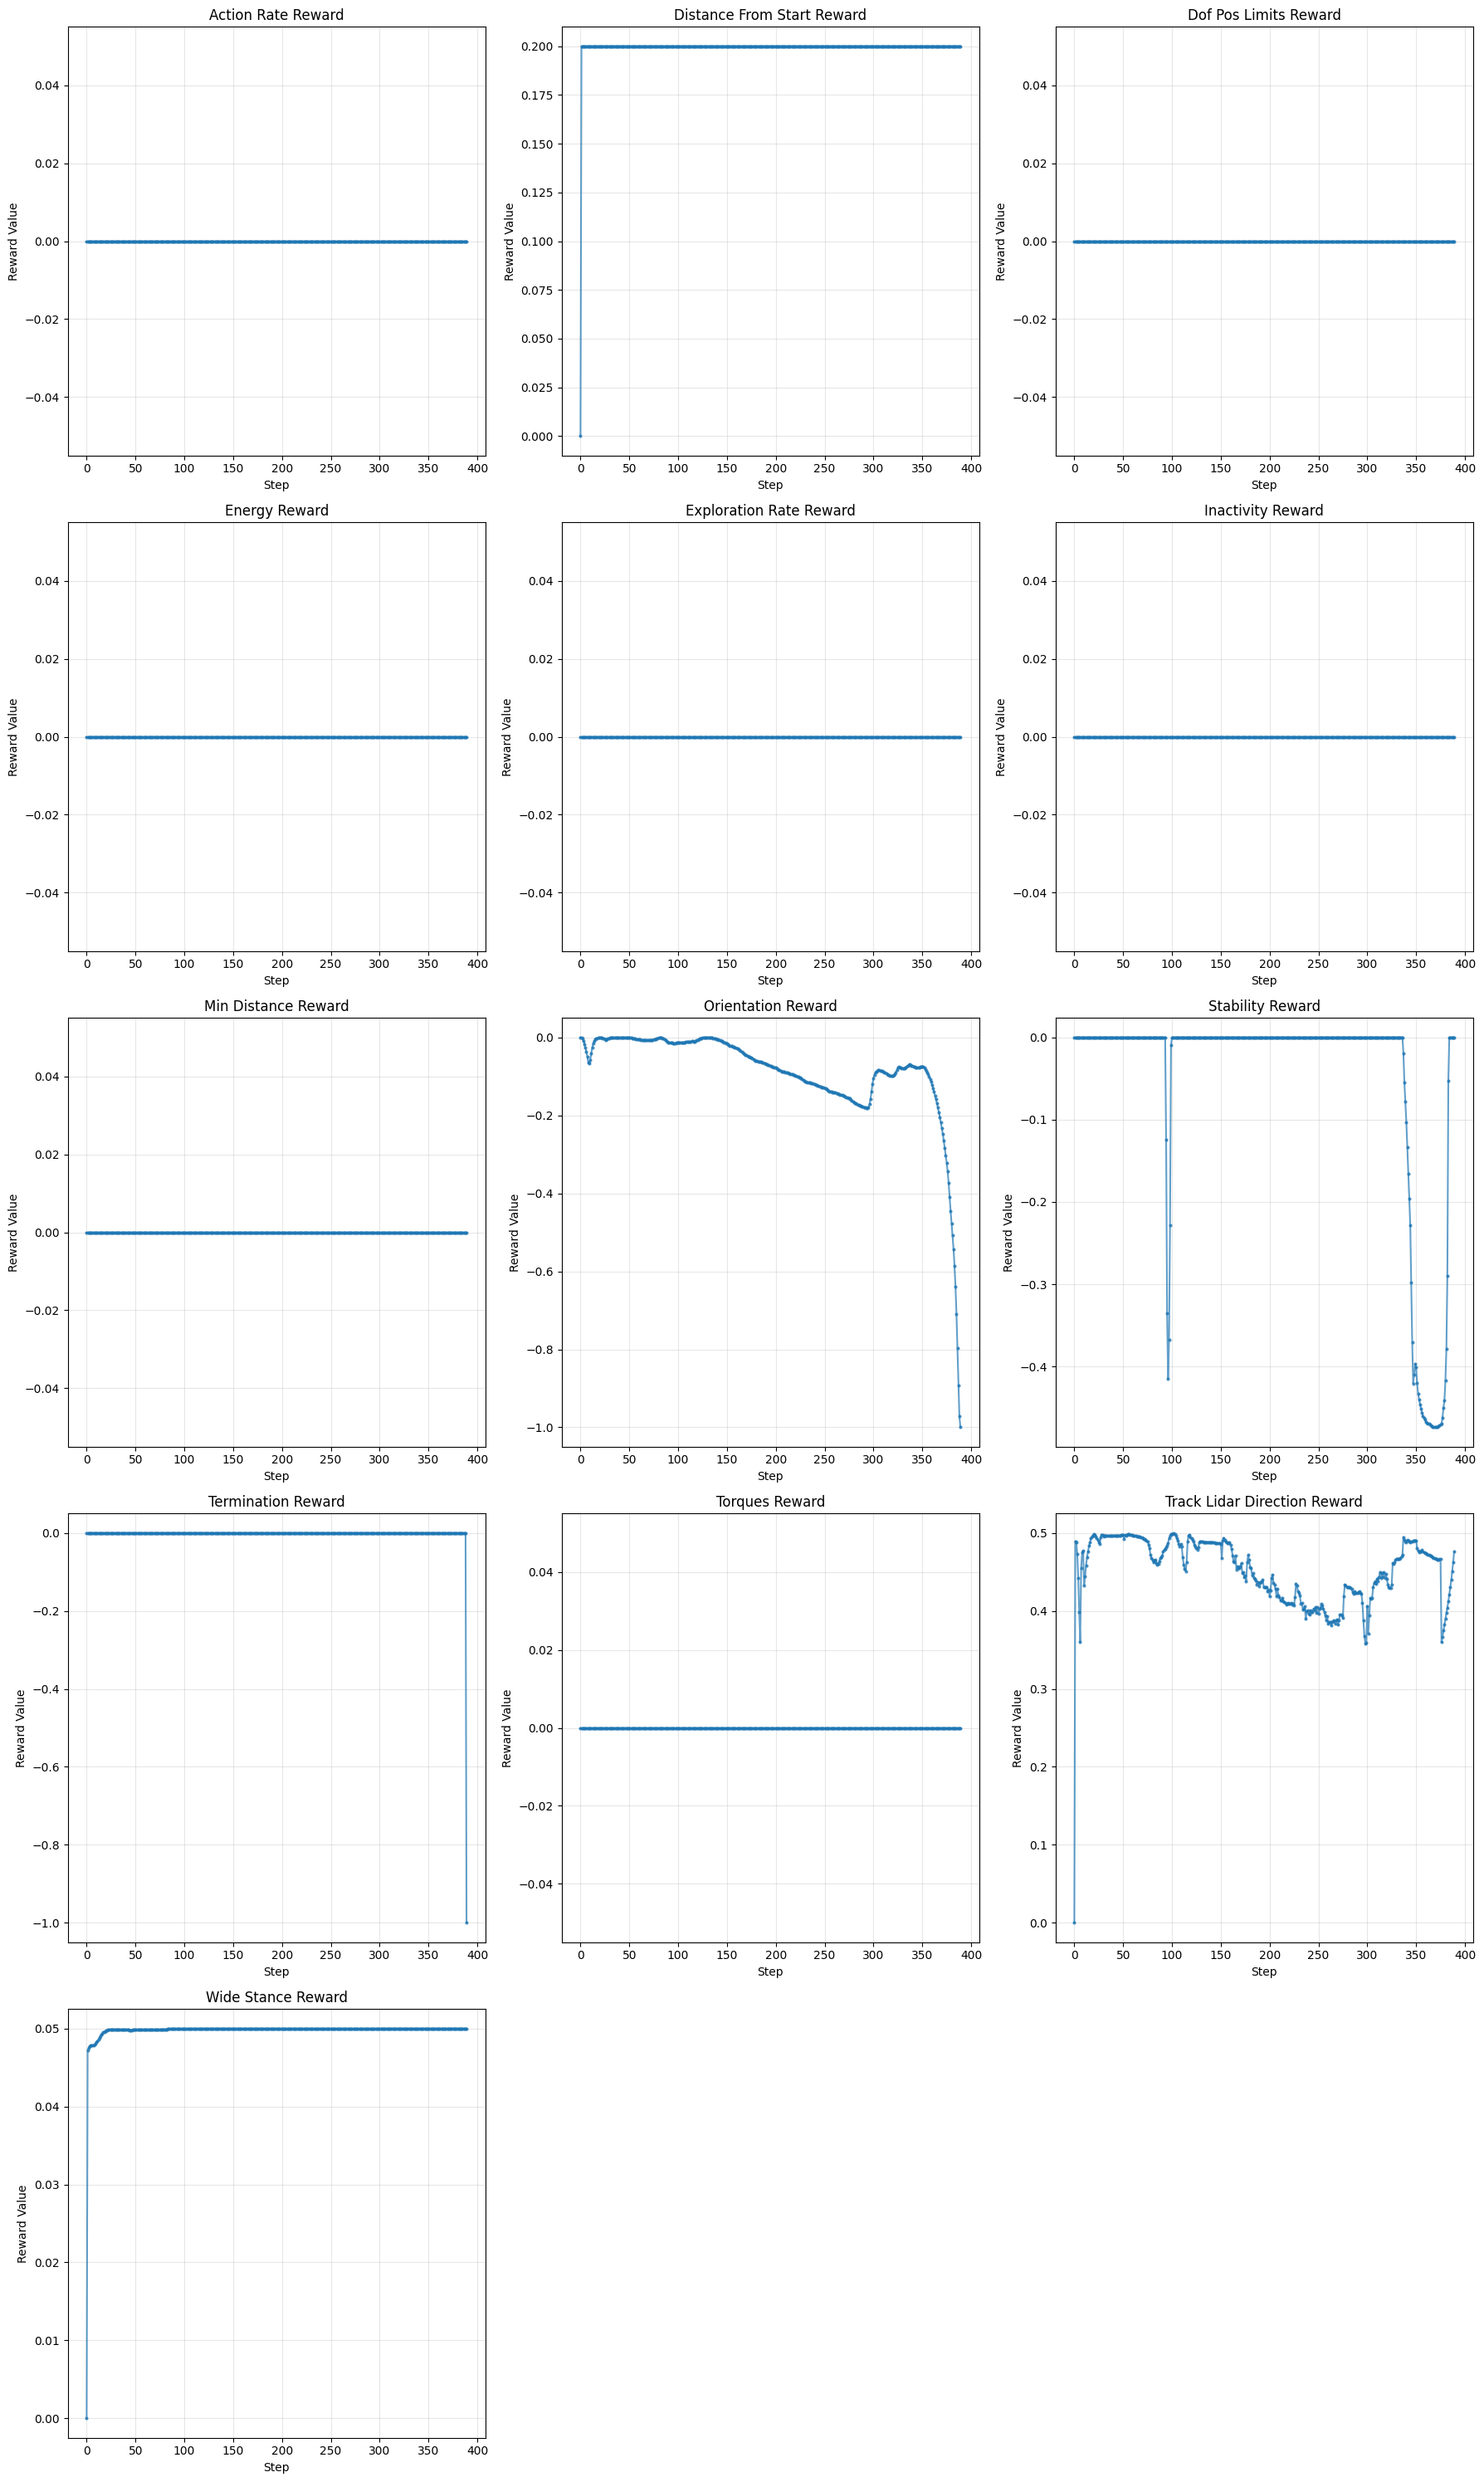

Individual Reward Statistics:
--------------------------------------------------
action_rate         : mean=  0.0000, std=  0.0000, min=  0.0000, max=  0.0000
distance_from_start : mean=  0.1995, std=  0.0101, min=  0.0000, max=  0.2000
dof_pos_limits      : mean=  0.0000, std=  0.0000, min=  0.0000, max=  0.0000
energy              : mean=  0.0000, std=  0.0000, min=  0.0000, max=  0.0000
exploration_rate    : mean=  0.0000, std=  0.0000, min=  0.0000, max=  0.0000
inactivity          : mean=  0.0000, std=  0.0000, min= -0.0000, max= -0.0000
min_distance        : mean=  0.0000, std=  0.0000, min= -0.0000, max= -0.0000
orientation         : mean= -0.0863, std=  0.1266, min= -0.9995, max=  0.0000
stability           : mean= -0.0495, std=  0.1357, min= -0.4738, max= -0.0000
termination         : mean= -0.0026, std=  0.0506, min= -1.0000, max=  0.0000
torques             : mean=  0.0000, std=  0.0000, min=  0.0000, max=  0.0000
track_lidar_direction: mean=  0.4529, std=  0.0439, min=  0.0

In [ ]:
# Extract individual rewards data
individual_rewards_data = {}
reward_steps = []

for entry in data:
    if 'individual_rewards' in entry:
        step = entry['step']
        reward_steps.append(step)
        
        for reward_name, reward_value in entry['individual_rewards'].items():
            if reward_name not in individual_rewards_data:
                individual_rewards_data[reward_name] = []
            individual_rewards_data[reward_name].append(reward_value)

# Create subplots for all individual rewards
reward_names = list(individual_rewards_data.keys())
num_rewards = len(reward_names)

# Calculate grid dimensions
cols = 3
rows = (num_rewards + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(18, 6 * rows))
axes = axes.flatten() if num_rewards > 1 else [axes]

# Plot each individual reward
for i, reward_name in enumerate(reward_names):
    axes[i].plot(reward_steps, individual_rewards_data[reward_name], marker='o', markersize=2, alpha=0.7)
    axes[i].set_title(f'{reward_name.replace("_", " ").title()} Reward')
    axes[i].set_xlabel('Step')
    axes[i].set_ylabel('Reward Value')
    axes[i].grid(True, alpha=0.3)

# Hide unused subplots
for i in range(num_rewards, len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.show()

# Print all reward graphs in a single figure
plt.figure(figsize=(12, 6))
for reward_name, values in individual_rewards_data.items():
    plt.plot(reward_steps, values, marker='o', markersize=2, label=reward_name.replace('_', ' ').title())
plt.title('Individual Rewards Over Steps')
plt.xlabel('Step')
plt.ylabel('Reward Value')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print statistics for each reward component
print("Individual Reward Statistics:")
print("-" * 50)
for reward_name, values in individual_rewards_data.items():
    values = np.array(values)
    print(f"{reward_name:20s}: mean={np.mean(values):8.4f}, std={np.std(values):8.4f}, min={np.min(values):8.4f}, max={np.max(values):8.4f}")

# Analyze action outputs

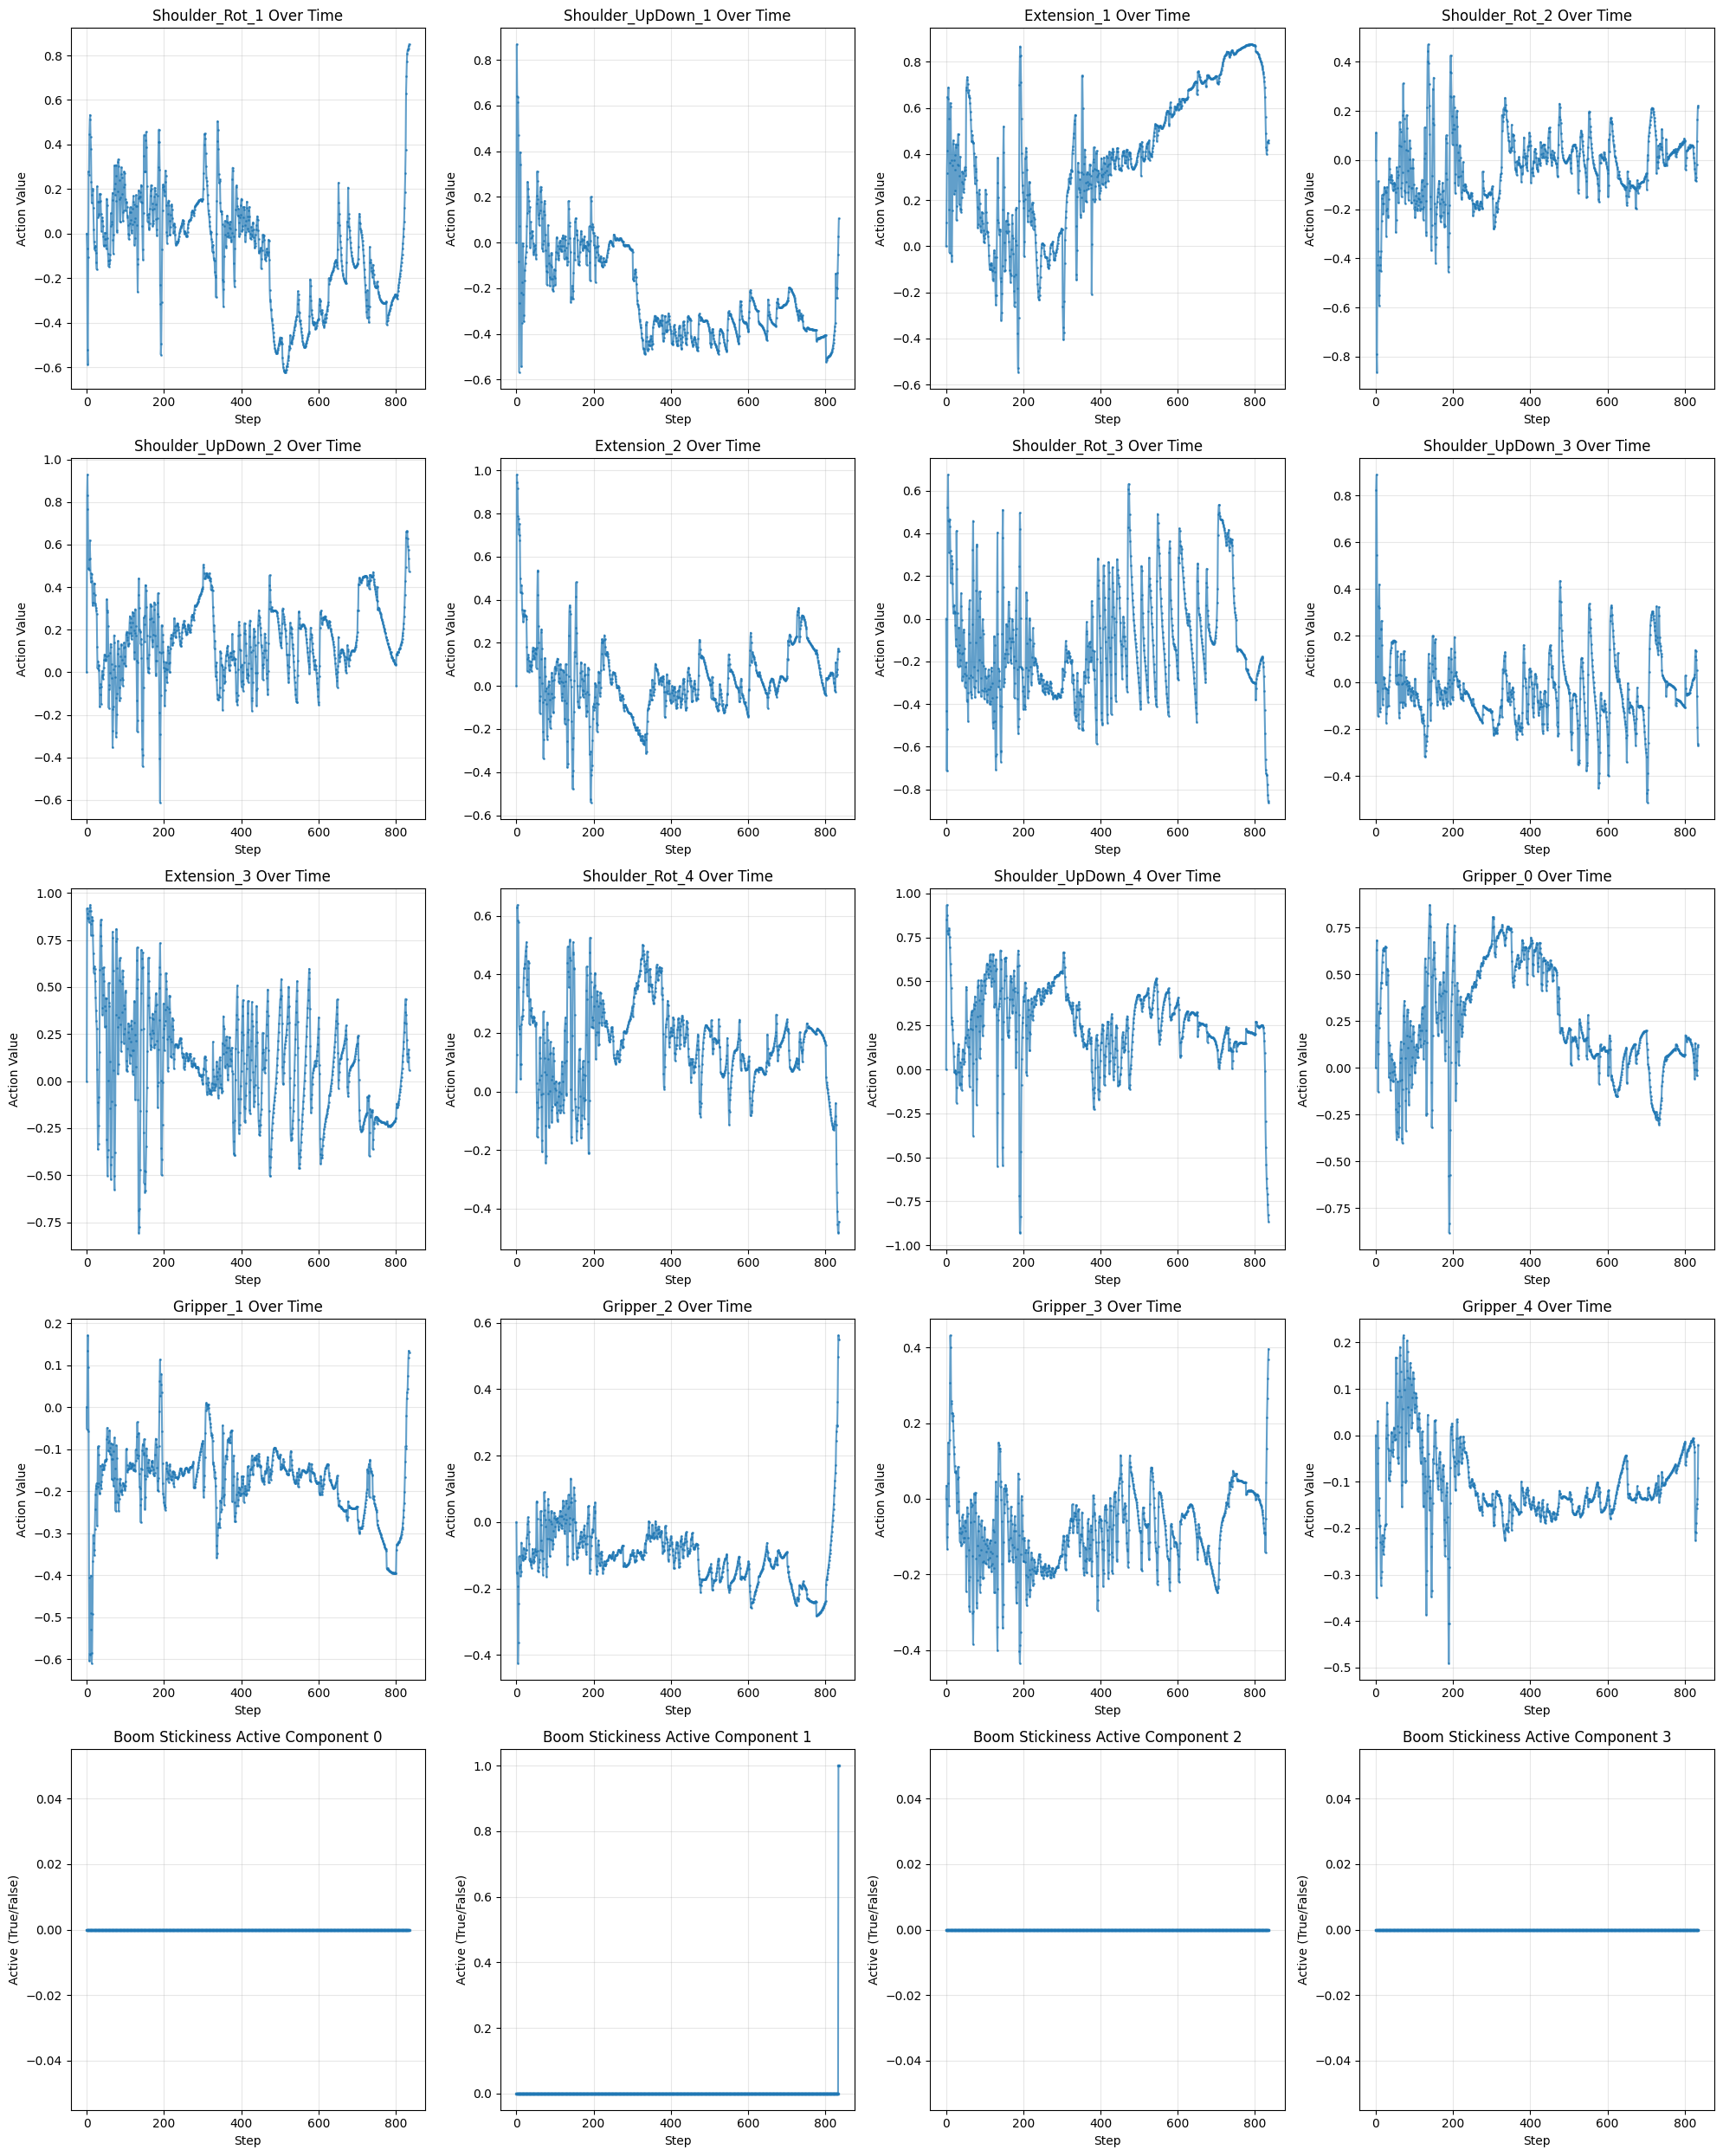

Action Statistics:
--------------------------------------------------
Shoulder_Rot_1 : mean= -0.0720, std=  0.2544, min= -0.6211, max=  0.8496
Shoulder_UpDown_1: mean= -0.2320, std=  0.1997, min= -0.5678, max=  0.8683
Extension_1    : mean=  0.3940, std=  0.3088, min= -0.5457, max=  0.8755
Shoulder_Rot_2 : mean= -0.0337, std=  0.1379, min= -0.8632, max=  0.4704
Shoulder_UpDown_2: mean=  0.1628, std=  0.1763, min= -0.6118, max=  0.9280
Extension_2    : mean=  0.0322, std=  0.1663, min= -0.5408, max=  0.9799
Shoulder_Rot_3 : mean= -0.1219, std=  0.2585, min= -0.8613, max=  0.6748
Shoulder_UpDown_3: mean= -0.0375, std=  0.1439, min= -0.5123, max=  0.8886
Extension_3    : mean=  0.0887, std=  0.2910, min= -0.8064, max=  0.9360
Shoulder_Rot_4 : mean=  0.1617, std=  0.1531, min= -0.4831, max=  0.6372
Shoulder_UpDown_4: mean=  0.2578, std=  0.2270, min= -0.9286, max=  0.9339
Gripper_0      : mean=  0.2540, std=  0.2868, min= -0.8815, max=  0.8691
Gripper_1      : mean= -0.1781, std=  0.0911, 

In [10]:
# Extract action outputs data
action_data = {}
action_steps = []
boom_stickiness_data = []
boom_stickiness_steps = []
action_names = ["Shoulder_Rot", "Shoulder_UpDown", "Extension"]

for entry in data:
    if 'info' in entry and 'last_act' in entry['info']:
        step = entry['step']
        action_steps.append(step)
        
        actions = entry['info']['last_act']
        for i, action_value in enumerate(actions):
            action_name = f"{action_names[i % 3]}_{i // 3 + 1}"  # Adjust action name to match the expected format
            if i >= 11:  # For gripper actions
                action_name = f'Gripper_{i-11}'
            if action_name not in action_data:
                action_data[action_name] = []
            action_data[action_name].append(action_value)
    
    if 'info' in entry and 'boom_stickiness_active' in entry['info']:
        boom_stickiness_steps.append(entry['step'])
        boom_stickiness_data.append(entry['info']['boom_stickiness_active'])

# Create subplots for all actions
action_names = list(action_data.keys())
num_actions = len(action_names)

# Calculate grid dimensions (including boom stickiness)
total_plots = num_actions + len(boom_stickiness_data[0]) if boom_stickiness_data else num_actions
cols = 4
rows = (total_plots + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(20, 5 * rows))
axes = axes.flatten() if total_plots > 1 else [axes]

# Plot each action
plot_idx = 0
for i, action_name in enumerate(action_names):
    axes[plot_idx].plot(action_steps, action_data[action_name], marker='o', markersize=1, alpha=0.7)
    axes[plot_idx].set_title(f'{action_name} Over Time')
    axes[plot_idx].set_xlabel('Step')
    axes[plot_idx].set_ylabel('Action Value')
    axes[plot_idx].grid(True, alpha=0.3)
    plot_idx += 1

# Plot boom stickiness components
if boom_stickiness_data:
    boom_array = np.array(boom_stickiness_data)
    num_boom_components = boom_array.shape[1]
    
    for i in range(num_boom_components):
        axes[plot_idx].plot(boom_stickiness_steps, boom_array[:, i], marker='s', markersize=2, alpha=0.7)
        axes[plot_idx].set_title(f'Boom Stickiness Active Component {i}')
        axes[plot_idx].set_xlabel('Step')
        axes[plot_idx].set_ylabel('Active (True/False)')
        axes[plot_idx].grid(True, alpha=0.3)
        plot_idx += 1

# Hide unused subplots
for i in range(plot_idx, len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.show()

# Print statistics
print("Action Statistics:")
print("-" * 50)
for action_name, values in action_data.items():
    values = np.array(values)
    print(f"{action_name:15s}: mean={np.mean(values):8.4f}, std={np.std(values):8.4f}, min={np.min(values):8.4f}, max={np.max(values):8.4f}")

if boom_stickiness_data:
    print("\nBoom Stickiness Statistics:")
    print("-" * 50)
    boom_array = np.array(boom_stickiness_data)
    for i in range(boom_array.shape[1]):
        component_data = boom_array[:, i]
        true_count = np.sum(component_data)
        total_count = len(component_data)
        print(f"Component {i:2d}: {true_count:4d}/{total_count:4d} active ({100*true_count/total_count:.1f}%)")